# Structured Data Pipeline — Real-World: Amazon Product Catalog

This notebook replaces the synthetic OHLCV data with the **Amazon Products dataset from Kaggle**,
demonstrating how the same Polars + RAPIDS cuDF structured-data pipeline adapts to real-world
product catalog analytics.

## Dataset
**Source**: Kaggle — `lokeshparab/amazon-products-dataset`  
**Files used**: All per-category CSVs in `DATA_DIR`, or `Amazon-Products.csv` (combined) as fallback  
**Schema**:
| Column | Raw format | Cleaned type |
|--------|-----------|-------------|
| `name` | string | `Utf8` |
| `main_category` | string | `Utf8` |
| `sub_category` | string | `Utf8` |
| `ratings` | `"4.2 out of 5 stars"` or `"4.2"` | `Float32` |
| `no_of_ratings` | `"1,234"` | `Int64` |
| `discount_price` | `"₹12,999"` | `Float64` |
| `actual_price` | `"₹15,999"` | `Float64` |

## How to get the data
```bash
# Option A — Kaggle CLI (recommended)
pip install kaggle
# Place your kaggle.json API key at ~/.kaggle/kaggle.json
kaggle datasets download -d lokeshparab/amazon-products-dataset --unzip -p ./data/amazon

# Option B — Manual download
# Visit the dataset page and download all CSVs, place them in DATA_DIR below.
```

The notebook auto-discovers **all** `.csv` files in `DATA_DIR` and loads them together.
`Amazon-Products.csv` (the pre-combined file) is treated as a single-file fallback if no
individual category CSVs are found.

## Pipeline mapping (synthetic → real)
| Synthetic concept | Amazon Products equivalent |
|-------------------|---------------------------|
| `symbol` | `name` (product title) |
| `asset_class` | `main_category` / source CSV filename |
| `close` price | `discount_price` |
| `open` price | `actual_price` |
| `volume` | `no_of_ratings` |
| price pct change | discount % = `(actual - discount) / actual * 100` |
| aggregate by period | aggregate by `sub_category` |

In [1]:
!kaggle datasets download -d lokeshparab/amazon-products-dataset --unzip -p ./data/amazon

Dataset URL: https://www.kaggle.com/datasets/lokeshparab/amazon-products-dataset
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100%|██████████████████████████████████████| 79.7M/79.7M [00:01<00:00, 57.5MB/s]



In [2]:
%load_ext cudf.pandas

## Setup

In [3]:
import logging
import sys
import time
from pathlib import Path

import numpy as np
import polars as pl

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")

# ── Configuration — update DATA_DIR to where you downloaded the Kaggle files ──
DATA_DIR = Path("./data/amazon").resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)

GPU_DEVICE = 0

# ── Auto-discover all category CSVs ───────────────────────────────────────────
# Exclude the pre-combined file — it will be used only as a fallback.
COMBINED_CSV = DATA_DIR / "Amazon-Products.csv"
SKIP_FILES   = {"Amazon-Products.csv", "Stores.csv"}   # Stores.csv has a different schema

category_csvs = sorted(
    p for p in DATA_DIR.glob("*.csv")
    if p.name not in SKIP_FILES
)

if not category_csvs and not COMBINED_CSV.exists():
    print("\nNo CSV files found — download from Kaggle:")
    print("  kaggle datasets download -d lokeshparab/amazon-products-dataset --unzip -p ./data/amazon")

# GPU detection — probe once with raise_on_fail=True so we know definitively, then
# build a *production* GPUEngine with raise_on_fail=False so per-op fallback is
# silent in the hot path.
try:
    pl.LazyFrame({"x": [1]}).collect(engine=pl.GPUEngine(device=GPU_DEVICE, raise_on_fail=True))
    GPU_ENGINE    = pl.GPUEngine(device=GPU_DEVICE, raise_on_fail=False)
    GPU_AVAILABLE = True
except Exception as ex:
    GPU_ENGINE    = None
    GPU_AVAILABLE = False
    print(f"\nGPU: not available ({ex}) — CPU fallback active")


def _engine(use_gpu: bool):
    return GPU_ENGINE if use_gpu and GPU_ENGINE is not None else "cpu"


def collect(lf: pl.LazyFrame, use_gpu: bool = GPU_AVAILABLE) -> pl.DataFrame:
    """Single-plan collect on the shared GPU engine (silent op-level CPU fallback)."""
    return lf.collect(engine=_engine(use_gpu))


def collect_all(lfs: list[pl.LazyFrame], use_gpu: bool = GPU_AVAILABLE) -> list[pl.DataFrame]:
    """Fuse N lazy plans into one optimizer pass — shared scans/filters run once.

    `pl.collect_all` in this Polars version only accepts string engine names, not
    a `GPUEngine` instance (unlike `LazyFrame.collect`). Try the configured engine
    first for forward-compat, fall back to the string form.
    """
    engine = _engine(use_gpu)
    try:
        return pl.collect_all(lfs, engine=engine)
    except TypeError:
        return pl.collect_all(lfs, engine="gpu" if use_gpu and GPU_ENGINE is not None else "cpu")


---
## Step 1 — Load and inspect the raw CSVs

Each category file uses the same schema but may have missing values in price/rating columns.
We `scan_csv` all files lazily, tag with the source category, concatenate, then
`.collect(engine="gpu")` so the parse + concat runs on the GPU when available.

In [4]:
READ_OPTS = dict(
    infer_schema_length=5000,
    ignore_errors=True,
    null_values=["", "NA", "N/A", "null", "None"],
)

if category_csvs:
    frames = [
        pl.scan_csv(p, **READ_OPTS).with_columns(pl.lit(p.stem).alias("source_category"))
        for p in category_csvs
    ]
elif COMBINED_CSV.exists():
    lf  = pl.scan_csv(COMBINED_CSV, **READ_OPTS)
    src = pl.col("main_category") if "main_category" in lf.collect_schema().names() else pl.lit("All")
    frames = [lf.with_columns(src.alias("source_category"))]
else:
    raise FileNotFoundError(
        f"No CSV files found in {DATA_DIR}.\n"
        "Download from Kaggle:\n"
        "  kaggle datasets download -d lokeshparab/amazon-products-dataset --unzip -p ./data/amazon"
    )

# Stay lazy — cleaning (next cell) fuses into the same plan and collects once on GPU.
# diagonal_relaxed handles minor schema differences across files.
raw_lf     = pl.concat(frames, how="diagonal_relaxed")
raw_schema = raw_lf.collect_schema()   # walks the plan, no execution
print(f"Discovered {len(frames)} CSV plan(s); {len(raw_schema)} columns: {raw_schema.names()}")


Discovered 139 CSV plan(s); 10 columns: ['name', 'main_category', 'sub_category', 'image', 'link', 'ratings', 'no_of_ratings', 'discount_price', 'actual_price', 'source_category']


---
## Step 2 — Data cleaning

The raw CSVs encode prices and ratings as messy strings. We clean them with Polars
string expressions — fully vectorized, runs on GPU when available.

**Price columns** (e.g. `₹12,999` or `$129.99`):
- Strip currency symbol (`₹`, `$`, `€`, `£`) and commas
- Cast to `Float64`

**Ratings column** (e.g. `"4.2 out of 5 stars"` or `"4.2"`):
- Extract the leading decimal number
- Cast to `Float32`

**no_of_ratings** (e.g. `"1,234"`):
- Remove commas, cast to `Int64`

In [5]:
def clean_price(col_name: str) -> pl.Expr:
    """Strip currency symbols and commas, cast to Float64."""
    return (
        pl.col(col_name)
        .cast(pl.Utf8)
        .str.replace_all(r"[₹$€£,\s]", "")
        .cast(pl.Float64, strict=False)
        .alias(col_name)
    )


def clean_rating(col_name: str) -> pl.Expr:
    """Extract leading float from strings like '4.2 out of 5 stars'."""
    return (
        pl.col(col_name)
        .cast(pl.Utf8)
        .str.extract(r"^([0-9]+\.?[0-9]*)", 1)
        .cast(pl.Float32, strict=False)
        .alias(col_name)
    )


def clean_rating_count(col_name: str) -> pl.Expr:
    """Remove commas from '1,234' style counts."""
    return (
        pl.col(col_name)
        .cast(pl.Utf8)
        .str.replace_all(",", "")
        .cast(pl.Int64, strict=False)
        .alias(col_name)
    )


# Detect which price/rating columns exist via the lazy plan's schema — no execution.
cols       = set(raw_schema.names())
price_cols = [c for c in ["discount_price", "actual_price"] if c in cols]
rating_col = "ratings"       if "ratings"       in cols else None
count_col  = "no_of_ratings" if "no_of_ratings" in cols else None

clean_exprs = [clean_price(c) for c in price_cols]
if rating_col:
    clean_exprs.append(clean_rating(rating_col))
if count_col:
    clean_exprs.append(clean_rating_count(count_col))

# Build ONE fused lazy plan: scan → concat → clean → derive → select → drop_nulls.
# Eliminates the previous collect→relazy→collect round-trip so the GPU sees the
# whole pipeline and the optimizer can pushdown projections + predicates.
products_lf = raw_lf.with_columns(clean_exprs)

if "discount_price" in cols and "actual_price" in cols:
    products_lf = products_lf.with_columns([
        # discount_pct ≈ "price return": how much cheaper than list price
        ((pl.col("actual_price") - pl.col("discount_price"))
         / pl.col("actual_price") * 100.0
        ).round(2).alias("discount_pct"),
        # savings in absolute terms
        (pl.col("actual_price") - pl.col("discount_price")).alias("savings"),
    ])

schema_cols = products_lf.collect_schema().names()
keep_cols = [c for c in ["name", "main_category", "sub_category", "source_category",
                          "ratings", "no_of_ratings", "discount_price", "actual_price",
                          "discount_pct", "savings"] if c in schema_cols]
products_lf = (
    products_lf
    .select(keep_cols)
    .drop_nulls(subset=[c for c in ["discount_price", "name"] if c in keep_cols])
)

# Single GPU collect — runs the full scan→clean→derive plan in one shot.
products = collect(products_lf, use_gpu=GPU_AVAILABLE)


---
## Step 3 — Exploratory analysis with Polars (CPU)

Quick EDA before switching to GPU — understand data distributions, spot outliers.

In [6]:
# Optional

---
## Step 4 — GPU-accelerated aggregations with Polars + cuDF

**This mirrors `PolarsPriceEngine.aggregate()`** — the pattern is identical:
build a lazy plan, `group_by` on a categorical key, apply aggregate functions, collect
with `engine="gpu"` (the cuDF backend; silently falls back to CPU if unavailable).

Instead of grouping by time period we group by **`sub_category`** (categorical dimension).

In [ ]:
# ── Aggregation 1: price stats by sub-category ─────────────────────────────────
agg_exprs = [
    pl.len().alias("product_count"),
]
if "discount_price" in products.columns:
    agg_exprs += [
        pl.col("discount_price").min().alias("price_min"),
        pl.col("discount_price").max().alias("price_max"),
        pl.col("discount_price").mean().round(2).alias("price_mean"),
        pl.col("discount_price").median().alias("price_median"),
    ]
if "discount_pct" in products.columns:
    agg_exprs.append(pl.col("discount_pct").mean().round(2).alias("avg_discount_pct"))
if "ratings" in products.columns:
    agg_exprs.append(pl.col("ratings").mean().round(3).alias("avg_rating"))
if "no_of_ratings" in products.columns:
    agg_exprs.append(pl.col("no_of_ratings").sum().alias("total_ratings"))

group_col = "sub_category" if "sub_category" in products.columns else "source_category"

category_stats = collect(
    products.lazy()
    .filter(pl.col(group_col).is_not_null())
    .group_by(group_col)
    .agg(agg_exprs)
    .sort("product_count", descending=True),
    use_gpu=GPU_AVAILABLE,
)


---
## Step 5 — Discount analysis: top deals by category

Mirrors `daily_price_pct_change()` — here discount % is the "price movement".
We find the highest-discount products within each category.

In [ ]:
if "discount_pct" in products.columns:
    # Filter implausible discounts AND keep only positive deals in one lazy chain —
    # no eager intermediate, optimizer fuses both predicates with the sort+groupby.
    top_deals = collect(
        products.lazy()
        .filter((pl.col("discount_pct") > 0) & (pl.col("discount_pct") <= 95))
        .sort("discount_pct", descending=True)
        .group_by("source_category")
        .head(5)              # top 5 per category after sort
        .select([
            "source_category", "name",
            "actual_price", "discount_price", "discount_pct",
            *(["ratings"] if "ratings" in products.columns else []),
        ])
        .sort(["source_category", "discount_pct"], descending=[False, True]),
        use_gpu=GPU_AVAILABLE,
    )
else:
    print("discount_pct column not available — check price columns in the CSV.")


---
## Step 6 — GPU vs CPU benchmark

Run the same `group_by` aggregation multiple times on CPU and GPU, then compare mean
latency to measure the speedup from `engine="gpu"`.

In [ ]:
N_RUNS = 5

# Build the lazy plan once and reuse it
bench_lf = (
    products.lazy()
    .filter(pl.col(group_col).is_not_null())
    .group_by(group_col)
    .agg(agg_exprs)
)

if GPU_AVAILABLE:
    collect(bench_lf, use_gpu=True)   # warmup
else:
    collect(bench_lf, use_gpu=False)  # warmup
    print("GPU not available — GPU benchmark skipped.")

---
## Step 7 — Rating quality analysis

The `ratings` × `no_of_ratings` combination gives a **Bayesian confidence-weighted quality
score** for each product — a common e-commerce ranking signal.

We compute it with Polars using the standard Wilson score lower bound approximation:
`score = (n * avg + z² / 2) / (n + z²)` where `z=1.96` for 95% confidence.

In [ ]:
if "ratings" in products.columns and "no_of_ratings" in products.columns:
    z2 = 1.96 ** 2  # 95% confidence
    n  = pl.col("no_of_ratings")
    p  = pl.col("ratings") / 5.0  # normalise 5-star rating to [0,1]

    rated_lf = (
        products.lazy()
        .filter(n.is_not_null() & (n > 0) & pl.col("ratings").is_not_null())
        .with_columns(
            # Wilson score lower bound
            ((p + z2 / (2 * n)) / (1 + z2 / n)).round(4).alias("wilson_score")
        )
    )

    top_rated_lf = (
        rated_lf
        .filter(pl.col("no_of_ratings") >= 100)
        .sort("wilson_score", descending=True)
        .head(10)
        .select(["name", "source_category", "discount_price", "ratings",
                 "no_of_ratings", "wilson_score"])
    )

    # Fuse both outputs into one optimizer pass — the shared filter+wilson stage
    # runs once, and Polars schedules both materializations on the same GPU pool.
    rated, top_rated = collect_all([rated_lf, top_rated_lf], use_gpu=GPU_AVAILABLE)
else:
    print("ratings / no_of_ratings columns not available.")


---
## Step 8 — Visualizations

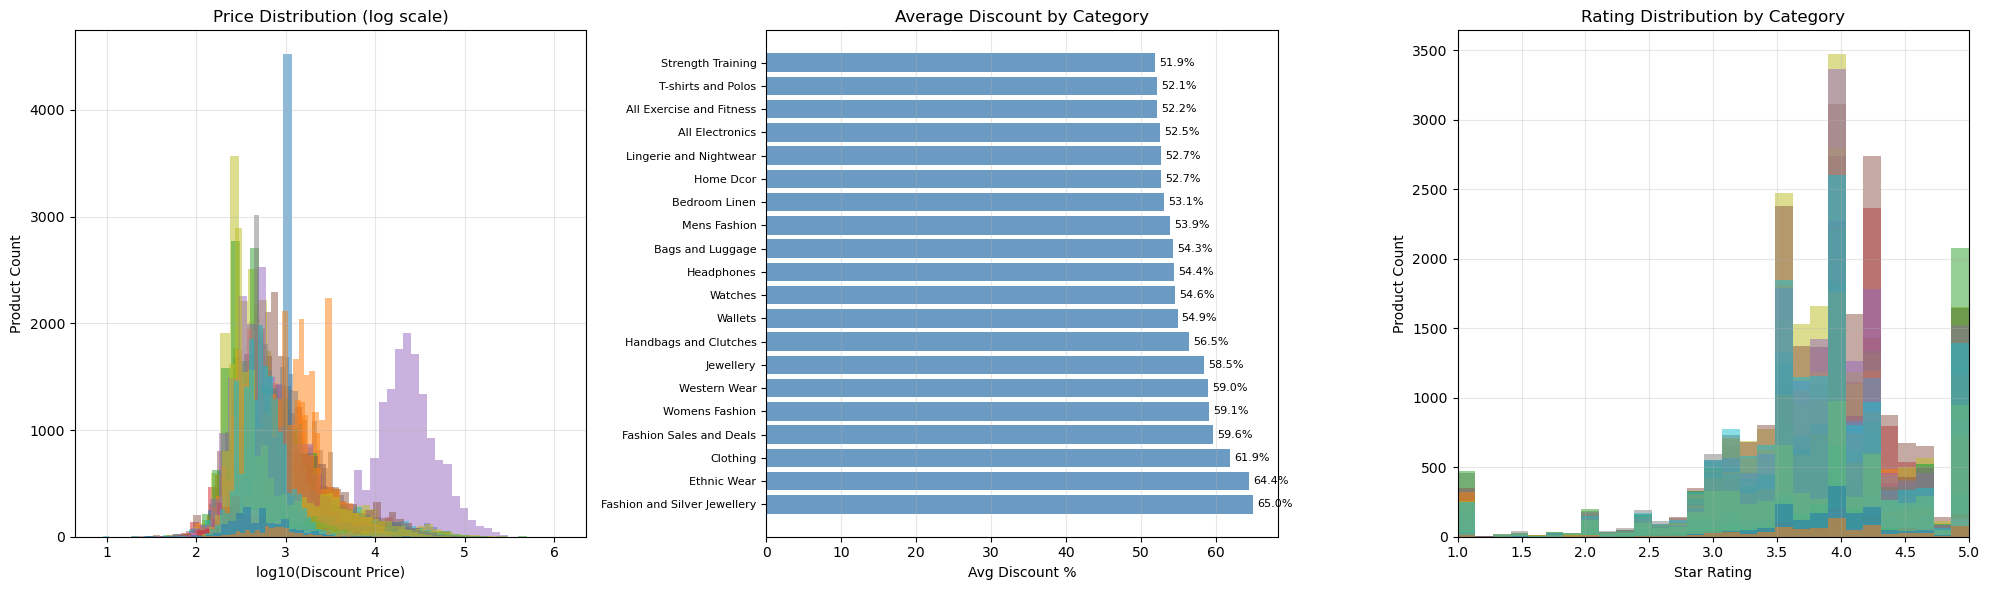

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

n_cats     = products["source_category"].n_unique()
fig_height = max(6, n_cats * 0.05)
fig, axes  = plt.subplots(1, 3, figsize=(20, fig_height))

# ── Replace N per-category collects with one fused batch ──────────────────────
# The previous version called `collect()` once per category per panel — that's
# 2·n_cats GPU round-trips. Here we build at most 3 lazy plans (prices, discount
# bars, ratings) and run them in a single `collect_all`, then partition on the
# host side, which is free.
has_disc = "discount_pct" in products.columns
has_rat  = "ratings"      in products.columns

prices_lf = (
    products.lazy()
    .filter(pl.col("discount_price").is_not_null() & (pl.col("discount_price") > 0))
    .select(["source_category", "discount_price"])
)

plans: list[pl.LazyFrame] = [prices_lf]
if has_disc:
    plans.append(
        products.lazy()
        .filter(
            pl.col("discount_pct").is_not_null()
            & (pl.col("discount_pct") >= 0)
            & (pl.col("discount_pct") <= 95)
        )
        .group_by("source_category")
        .agg(pl.col("discount_pct").mean().round(1).alias("avg_disc"))
        .sort("avg_disc", descending=True)
        .head(20)
    )
if has_rat:
    plans.append(
        products.lazy()
        .filter(pl.col("ratings").is_not_null())
        .select(["source_category", "ratings"])
    )

results   = iter(collect_all(plans, use_gpu=GPU_AVAILABLE))
prices_df = next(results)
cat_disc  = next(results) if has_disc else None
rat_df    = next(results) if has_rat  else None

# Partition on the host — data is already materialised, this is just slicing.
prices_by_cat = {
    cat: df["discount_price"].to_numpy()
    for cat, df in prices_df.partition_by("source_category", as_dict=True).items()
}
ratings_by_cat = (
    {} if rat_df is None
    else {
        cat: df["ratings"].to_numpy()
        for cat, df in rat_df.partition_by("source_category", as_dict=True).items()
    }
)

# ── (A) Price distribution per category ───────────────────────────────────────
ax = axes[0]
for cat in sorted(prices_by_cat):
    prices_cat = prices_by_cat[cat]
    if len(prices_cat) > 0:
        ax.hist(np.log10(np.clip(prices_cat, 1, None)), bins=40, alpha=0.5, label=cat)
ax.set_xlabel("log10(Discount Price)")
ax.set_ylabel("Product Count")
ax.set_title("Price Distribution (log scale)")
ax.grid(alpha=0.3)

# ── (B) Average discount % by category ────────────────────────────────────────
ax = axes[1]
if cat_disc is not None:
    cats  = cat_disc["source_category"].to_list()
    discs = cat_disc["avg_disc"].to_list()
    bars  = ax.barh(cats, discs, color="steelblue", alpha=0.8)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_xlabel("Avg Discount %")
    ax.set_title("Average Discount by Category")
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(alpha=0.3, axis="x")
else:
    ax.text(0.5, 0.5, "discount_pct unavailable", ha="center", va="center")

# ── (C) Rating distribution ────────────────────────────────────────────────────
ax = axes[2]
if ratings_by_cat:
    for cat in sorted(ratings_by_cat):
        r = ratings_by_cat[cat]
        if len(r) > 0:
            ax.hist(r, bins=np.linspace(1, 5, 30), alpha=0.5, label=cat)
    ax.set_xlabel("Star Rating")
    ax.set_ylabel("Product Count")
    ax.set_title("Rating Distribution by Category")
    ax.set_xlim(1, 5)
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, "ratings unavailable", ha="center", va="center")

plt.tight_layout()
plt.savefig(DATA_DIR / "amazon_products_overview.png", dpi=130, bbox_inches="tight")
plt.show()

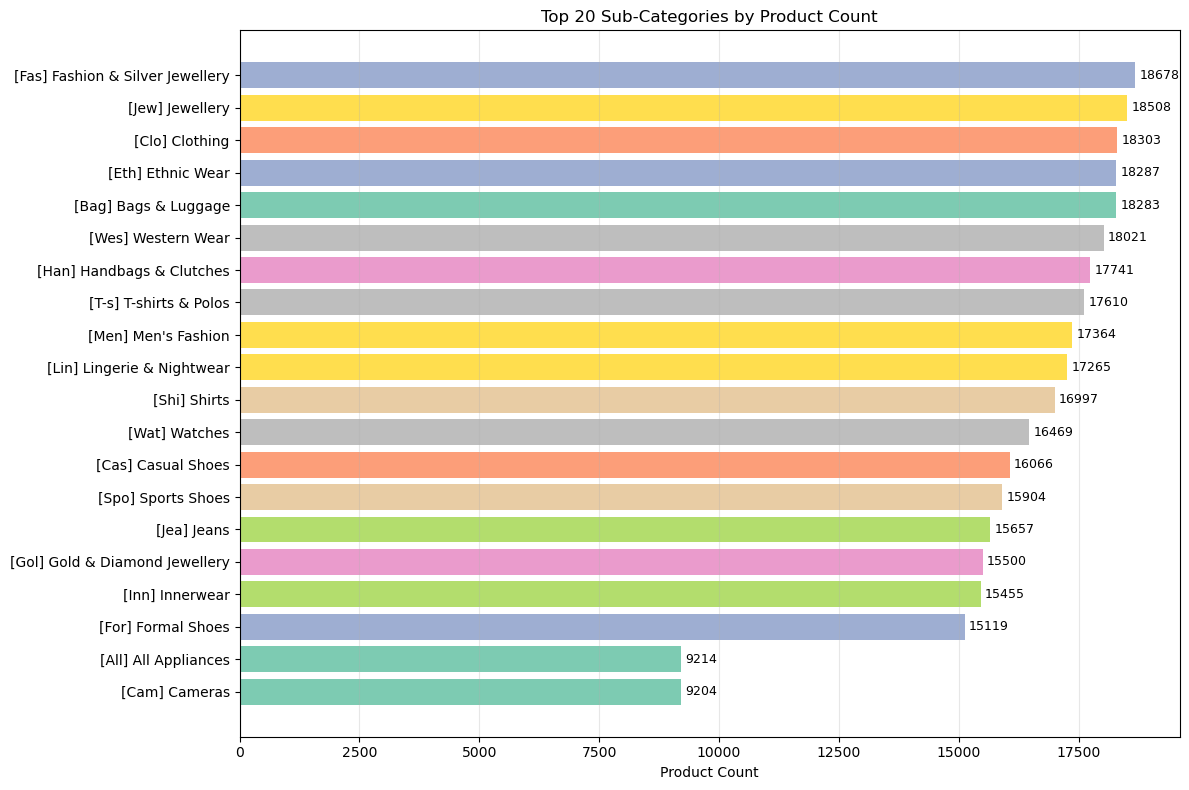

In [ ]:
# Top 20 sub-categories by product count — horizontal bar chart
if "sub_category" in products.columns:
    top_subs = collect(
        products.lazy()
        .filter(pl.col("sub_category").is_not_null())
        .group_by(["source_category", "sub_category"])
        .agg(
            pl.len().alias("count"),
            *([pl.col("discount_price").median().round(0).alias("median_price")]
              if "discount_price" in products.columns else []),
        )
        .sort("count", descending=True)
        .head(20),
        use_gpu=GPU_AVAILABLE,
    )

    labels = [
        f"[{row['source_category'][:3]}] {row['sub_category'][:35]}"
        for row in top_subs.iter_rows(named=True)
    ]
    counts = top_subs["count"].to_list()
    palette = plt.cm.Set2(np.linspace(0, 1, len(set(top_subs["source_category"].to_list()))))
    cat_color = {c: palette[i] for i, c in enumerate(sorted(set(top_subs["source_category"].to_list())))}
    colors = [cat_color[r] for r in top_subs["source_category"].to_list()]

    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.barh(labels, counts, color=colors, alpha=0.85)
    ax.bar_label(bars, fmt="%d", padding=3, fontsize=9)
    ax.set_xlabel("Product Count")
    ax.set_title("Top 20 Sub-Categories by Product Count")
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(DATA_DIR / "amazon_subcategories.png", dpi=130)
    plt.show()


---
## Step 9 — Export clean data for the unstructured pipeline

Write the cleaned Polars DataFrame as Parquet so `02_unstructured_amazon_reviews.ipynb`
can load it directly without re-running the cleaning logic.

In [ ]:
out_path = DATA_DIR / "amazon_products_clean.parquet"
products.write_parquet(out_path)
size_mb = out_path.stat().st_size / 1e6


---
## Step 10 — Optional fallback: Presto / SQL engine path

**When to use this**: as a drop-in alternative to Steps 4–6 when GPU Polars
isn't available on the host. Same inputs (the Step 9 parquet), same output
variables (`category_stats`, `top_deals`), just executed by Presto over SQL
instead of by Polars + cuDF in-process.

Default image is the standard Java Presto (`prestodb/presto:latest`) with
its built-in config — we only add a hive catalog file. For full GPU push-down,
swap in NVIDIA's cuDF-enabled Velox worker (see `presto/Dockerfile` in the
GTC26-BFD reference); every SQL statement below is unchanged.

### Prerequisites
- Docker on the host (`docker version` must work)
- Free TCP port `8089`
- `pip install presto-python-client`

### Cells (in order)
1. **Bootstrap + start** — writes `presto/catalog/amazon.properties`, stages
   the Step 9 parquet, runs `docker run prestodb/presto:latest`
2. **Wait** — polls `/v1/info` until ready
3. **Connect + register** — `CREATE SCHEMA` + `CREATE TABLE` over the staged
   parquet
4. **Step 10a/b** — aggregation + top-deals, mirroring Steps 4 and 5
5. **Teardown** — `docker rm -f amazon-presto`

In [ ]:
"""Bootstrap + start Presto in one go.

Keeps the standard image's default config (heap, jvm, node, ports) — we only
add a single hive catalog file so we can register the Step 9 parquet.
"""
import shutil
import subprocess
from pathlib import Path

PROJECT_ROOT   = Path.cwd()
PRESTO_CATALOG = PROJECT_ROOT / "presto" / "catalog"
PRESTO_CATALOG.mkdir(parents=True, exist_ok=True)

# Hive points at a *directory*, not a single file — stage parquet accordingly.
PRESTO_TABLE_DIR = DATA_DIR / "presto_products"
PRESTO_TABLE_DIR.mkdir(exist_ok=True)
src_parquet = DATA_DIR / "amazon_products_clean.parquet"
if not src_parquet.exists():
    raise FileNotFoundError(f"Run Step 9 first — {src_parquet} not found")
shutil.copy2(src_parquet, PRESTO_TABLE_DIR / "products.parquet")

# The ONLY config we override: a hive catalog with a file-based metastore.
(PRESTO_CATALOG / "amazon.properties").write_text(
    "connector.name=hive-hadoop2\n"
    "hive.metastore=file\n"
    "hive.metastore.catalog.dir=file:/var/lib/presto/data/hive/metastore\n"
    "hive.allow-drop-table=true\n"
)

# Tear down any prior container with this name, then start fresh.
subprocess.run(["docker", "rm", "-f", "amazon-presto"], capture_output=True)
result = subprocess.run(
    [
        "docker", "run", "-d",
        "--name", "amazon-presto",
        "-p", "8089:8080",
        "-v", f"{(PRESTO_CATALOG / 'amazon.properties').resolve()}"
              ":/opt/presto-server/etc/catalog/amazon.properties:ro",
        "-v", f"{PRESTO_TABLE_DIR.resolve()}:/data/products:ro",
        "prestodb/presto:latest",
    ],
    capture_output=True, text=True,
)
if result.returncode != 0:
    print(result.stderr or "(no stderr)")
    raise RuntimeError(f"`docker run` exited with code {result.returncode}")

### Wait for Presto to be ready

First run pulls the image (~600 MB) so this can take a minute. Subsequent
runs reuse the cached layers and Presto starts in ~10s.

In [ ]:
import json
import time
import urllib.request

PRESTO_URL = "http://localhost:8089"
deadline = time.time() + 180  # first-run image pull can be slow
while time.time() < deadline:
    try:
        with urllib.request.urlopen(f"{PRESTO_URL}/v1/info", timeout=2) as resp:
            info = json.loads(resp.read())
            if info.get("starting") is False:
                print(f"Presto ready — node version {info['nodeVersion']['version']}")
                break
    except Exception:
        pass
    time.sleep(2)
else:
    raise RuntimeError(
        "Presto did not start in 180s — check `docker logs amazon-presto`"
    )

Presto ready — node version 0.297-6c8e90a


### Connect & register the Hive external table

Point Presto at the staged parquet directory and declare a schema-on-read
table. Column types must match the parquet's Arrow schema.

In [ ]:
try:
    from prestodb import dbapi as prestodb_dbapi
except ImportError as exc:
    raise ImportError(
        "Install the Presto client first:  pip install presto-python-client"
    ) from exc

conn = prestodb_dbapi.connect(
    host="localhost", port=8089,
    user="amazon-notebook",
    catalog="amazon", schema="default",
)


def sql(query: str):
    """Run a Presto query, return (rows, column_names)."""
    cur = conn.cursor()
    cur.execute(query)
    rows = cur.fetchall()
    cols = [d[0] for d in cur.description] if cur.description else []
    return rows, cols


def sql_df(query: str) -> pl.DataFrame:
    """Run a Presto query, return a Polars DataFrame."""
    rows, cols = sql(query)
    return pl.DataFrame([dict(zip(cols, r)) for r in rows]) if rows else pl.DataFrame()


# Schema + external table — both idempotent. With the file-based Hive metastore
# we omit the schema-level `location` (Hive rejects it: "Database can not be
# created with a location set"). The table's `external_location` is where Hive
# actually looks for the parquet data.
sql("CREATE SCHEMA IF NOT EXISTS amazon.default")
sql("""
    CREATE TABLE IF NOT EXISTS amazon.default.products (
        name            VARCHAR,
        main_category   VARCHAR,
        sub_category    VARCHAR,
        source_category VARCHAR,
        ratings         REAL,
        no_of_ratings   BIGINT,
        discount_price  DOUBLE,
        actual_price    DOUBLE,
        discount_pct    DOUBLE,
        savings         DOUBLE
    )
    WITH (
        external_location = 'file:///data/products',
        format = 'PARQUET'
    )
""")

### Aggregations — same outputs as Steps 4–5, via SQL

| New cell | Mirrors | Output variable |
|----------|---------|-----------------|
| Step 10a | Step 4 (`cell-05-gpu-agg`) | `category_stats` |
| Step 10b | Step 5 (`cell-06-discount`) | `top_deals` |

In [ ]:
# Step 10a — same shape as Polars `group_by(sub_category).agg(...)` in
# `cell-05-gpu-agg`. `APPROX_PERCENTILE(_, 0.5)` is SQL's equivalent of
# Polars `.median()`.
category_stats = sql_df("""
    SELECT
        sub_category,
        COUNT(*)                                AS product_count,
        MIN(discount_price)                     AS price_min,
        MAX(discount_price)                     AS price_max,
        ROUND(AVG(discount_price), 2)           AS price_mean,
        APPROX_PERCENTILE(discount_price, 0.5)  AS price_median,
        ROUND(AVG(discount_pct), 2)             AS avg_discount_pct,
        ROUND(AVG(ratings), 3)                  AS avg_rating,
        SUM(no_of_ratings)                      AS total_ratings
    FROM amazon.default.products
    WHERE sub_category IS NOT NULL
    GROUP BY sub_category
    ORDER BY product_count DESC
""")
category_stats

In [ ]:
# Step 10b — same as Polars `sort + group_by.head(5)` in `cell-06-discount`.
# In SQL: window-rank within each category, keep rn <= 5.
top_deals = sql_df("""
    WITH ranked AS (
        SELECT
            source_category,
            name,
            actual_price,
            discount_price,
            discount_pct,
            ratings,
            ROW_NUMBER() OVER (
                PARTITION BY source_category
                ORDER BY discount_pct DESC
            ) AS rn
        FROM amazon.default.products
        WHERE discount_pct > 0 AND discount_pct <= 95
    )
    SELECT source_category, name, actual_price, discount_price, discount_pct, ratings
    FROM ranked
    WHERE rn <= 5
    ORDER BY source_category, discount_pct DESC
""")
top_deals

### Teardown

Stops the Presto container. The file-based Hive metastore lives **inside** the
container, so re-running this section from the top recreates the catalog from
scratch — the parquet on disk is untouched.

In [ ]:
try:
    conn.close()
except Exception:
    pass

import subprocess
subprocess.run(["docker", "rm", "-f", "amazon-presto"], capture_output=True)
print("Stopped & removed amazon-presto container")

Stopped & removed amazon-presto container


---
## Summary

| Step | Tool(s) | What happened |
|------|---------|---------------|
| 1 | Polars `scan_csv` + `collect(engine="gpu")` | Auto-discovered and loaded **all** category CSVs from `DATA_DIR` via a lazy plan executed on GPU; falls back to `Amazon-Products.csv` if individual files not present |
| 2 | Polars string expressions | Cleaned prices (₹/$), ratings, review counts |
| 3 | Polars `describe`, `group_by` | EDA: row counts, null checks across all categories |
| 4 | **Polars + cuDF** (`engine="gpu"`) | GPU-accelerated price/rating aggregation by sub-category |
| 5 | Polars `sort` + `group_by.head` | Top-discount products per category |
| 6 | `engine="gpu"` benchmark | CPU vs GPU timing on aggregation |
| 7 | Polars window expressions | Wilson confidence score for rating quality |
| 8 | matplotlib | Price distribution, discount %, rating histogram, sub-category bar chart |
| 9 | Polars `write_parquet` | Exported clean data for `02_unstructured_amazon_reviews.ipynb` and the Streamlit dashboard |
| 10 (fallback) | **Presto + Hive external table** | Drop-in alternative to Steps 4–5 when GPU Polars isn't available; produces the same `category_stats` and `top_deals` variables via SQL |

**Next**: `02_unstructured_amazon_reviews.ipynb` — embed review text, run semantic search, cluster by topic.